In [7]:
# Standard library
import json
import re
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Parsing
from bs4 import BeautifulSoup

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Agreement metrics (use these in the annotator-agreement step)
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

# Convenience
from tqdm.auto import tqdm

/Users/paolohalog/CookieMonsterNotebookTest/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Websites Covered
Going through three files:
- websites_at100
- websites_covered_opp115
- websites_opp115

Attempt: trying to build an understanding of what the context of each of these files are

In [8]:
## websites_at100
df_web100 = pd.read_csv('/Users/paolohalog/Downloads/OPP-115/documentation/websites_at100.csv')
df_web100.head()

,Website UID,Site URL,Human Readable Site Name,Policy UID,Website Check Date,In 115 Set,Comments,Categories,Unnamed: 8,Unnamed: 9,...,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104,Unnamed: 105,Unnamed: 106
0,1040,google.com,Google,591,2016-02-24,YES,NaN,Regional: North America: United States: Colora...,Regional: North America: United States: Colora...,Regional: North America: United States: Washin...,...,Society: Religion and Spirituality: Christiani...,Sports: Korfball: Clubs,Sports: Running: Clubs: Europe: United Kingdom...,Sports: Water Sports: Swimming and Diving: Reg...,World: Català: Arts i cultura: Música: Estils:...,World: Català: Regional: Catalunya: Barcelona:...,World: Esperanto: Socio: Junuloj: Aranĝoj: Int...,World: Français: Régional: Europe: France: Spo...,World: Hebrew: בריאות: ארגונים ואגודות,World: Nederlands: Maatschappij: Religie en Sp...
1,10000,facebook.com,Facebook,2,2016-02-24,NO,NaN,Regional: North America: United States: Georgi...,Regional: North America: United States: Illino...,Regional: North America: United States: Califo...,...,Regional: North America: United States: Wiscon...,Society: Organizations: Student: Fraternities ...,Society: Religion and Spirituality: Christiani...,Society: Religion and Spirituality: Christiani...,Society: Religion and Spirituality: Christiani...,Sports: Cheerleading: College and University: ...,Sports: Flying Discs: Disc Golf: Clubs,Sports: Flying Discs: Ultimate Frisbee: Teams:...,Sports: Flying Discs: Ultimate Frisbee: Teams:...,World: Dansk: Samfund: Forsvaret: Hjemmeværnet...
2,1038,youtube.com,Youtube,591,2016-02-24,YES,Google's privacy policy,World: Español: Regional: América: Argentina: ...,World: Esperanto: Kulturo: Muziko: Esperanto-m...,World: Español: Regional: América: Uruguay: De...,...,"Arts: Music: Bands and Artists: P: Pagano, Lin...",Arts: Music: Bands and Artists: R: R.E.M.,Arts: Music: Bands and Artists: S: Sy: System ...,Arts: Music: Bands and Artists: T: Taking Back...,Arts: Music: Composition: Composers: Contempor...,Arts: Music: DJs: Personal Pages: D,Arts: Music: Instruments: Percussion: Hang: Ba...,Arts: Music: Songwriting: Songwriters: F,Arts: Music: Styles: B: Blues: Bands and Artis...,"Arts: Music: Vocal: Singers: Jazz: R: Raney, Sue"
3,12,amazon.com,Amazon,105,2016-02-24,YES,NaN,Computers: Programming: Languages: Smalltalk: ...,Society: Issues: Business: Allegedly Unethical...,"Arts: Literature: Authors: L: Lethem, Jonathan...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1063,yahoo.com,Yahoo!,1361,2016-02-24,YES,Redirects to an annotated policy,World: Español: Regional: América: Chile: Soci...,World: Español: Regional: América: Chile: Soci...,Society: Organizations: Fraternal: Freemasonry...,...,Business: Agriculture and Forestry: Livestock:...,Computers: Software: Graphics: 3D: Rendering a...,Health: Addictions: Substance Abuse: Alcohol: ...,Recreation: Autos: Makes and Models: Subaru: C...,Recreation: Birding: North America: United Sta...,Recreation: Collecting: Toys: Lego: User Group...,Recreation: Pets: Dogs: Training: Clicker Trai...,Regional: North America: United States: Govern...,Society: Issues: Environment: Noise Pollution:...,Society: Organizations: Student: Fraternities ...


In [12]:
df_web100.columns.tolist()

['Website UID',
 'Site URL',
 'Human Readable Site Name',
 'Policy UID',
 'Website Check Date',
 'In 115 Set',
 'Comments',
 'Categories',
 'Unnamed: 8',
 'Unnamed: 9',
 'Unnamed: 10',
 'Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22',
 'Unnamed: 23',
 'Unnamed: 24',
 'Unnamed: 25',
 'Unnamed: 26',
 'Unnamed: 27',
 'Unnamed: 28',
 'Unnamed: 29',
 'Unnamed: 30',
 'Unnamed: 31',
 'Unnamed: 32',
 'Unnamed: 33',
 'Unnamed: 34',
 'Unnamed: 35',
 'Unnamed: 36',
 'Unnamed: 37',
 'Unnamed: 38',
 'Unnamed: 39',
 'Unnamed: 40',
 'Unnamed: 41',
 'Unnamed: 42',
 'Unnamed: 43',
 'Unnamed: 44',
 'Unnamed: 45',
 'Unnamed: 46',
 'Unnamed: 47',
 'Unnamed: 48',
 'Unnamed: 49',
 'Unnamed: 50',
 'Unnamed: 51',
 'Unnamed: 52',
 'Unnamed: 53',
 'Unnamed: 54',
 'Unnamed: 55',
 'Unnamed: 56',
 'Unnamed: 57',
 'Unnamed: 58',
 'Unnamed: 59',
 'Unnamed: 60',
 'Unnamed: 61',

In [13]:
df_web100.isnull().sum()

Website UID                  0
Site URL                     0
Human Readable Site Name     1
Policy UID                   0
Website Check Date           0
                            ..
Unnamed: 102                64
Unnamed: 103                65
Unnamed: 104                65
Unnamed: 105                65
Unnamed: 106                65
Length: 107, dtype: int64

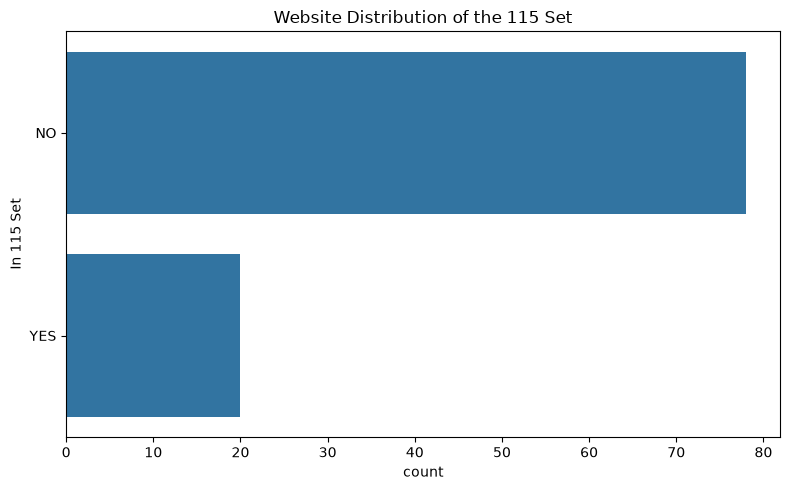

In [35]:
order = df_web100["In 115 Set"].value_counts().index
plt.figure(figsize=(8, 5))
sns.countplot(data=df_web100, y="In 115 Set", order=order)
plt.title("Website Distribution of the 115 Set")
plt.tight_layout()
plt.show()

In [3]:
## websites_covered_opp115
df_webinOPP = pd.read_csv('/Users/paolohalog/Downloads/OPP-115/documentation/websites_covered_opp115.csv')
df_webinOPP.head()

,Site UID,Site URL,Site Human-Readable Name,Policy UID,Site Check Date,In 115 Set?,Comments,Sectoral Data,Unnamed: 8,Unnamed: 9,...,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104,Unnamed: 105,Unnamed: 106
0,1,theatlantic.com,The Atlantic,20,2016-02-08,Yes,"Alexa Rank: 975 (Global), 289 (US)","Arts: Literature: Authors: A: Alcott, Louisa M...","Arts: Literature: Authors: M: Merwin, W. S.: W...",Arts: Literature: World Literature: American: ...,...,Regional: North America: United States: Tennes...,Regional: North America: United States: Vermon...,Regional: North America: United States: Washin...,Regional: Oceania: Australia: New South Wales:...,Science: Agriculture: Crop Plants: Coffee,Science: Astronomy: Solar System: Dwarf Planet...,Science: Biology: Microbiology: Virology,Science: Earth Sciences: Atmospheric Sciences:...,Science: Social Sciences: Economics: Economic ...,Science: Social Sciences: Economics: People: G...
1,2,imdb.com,IMDb,21,2016-02-08,Yes,"Alexa Rank: 49 (Global), 27 (US)",Kids and Teens: Entertainment: Animation: Movies,Regional: Europe: United Kingdom: Arts and Ent...,Arts: Performing Arts: Magic: Magicians: Siegf...,...,"Arts: People: S: Sagal, Jean and Liz","Arts: People: W: Wilde, Lyn and Lee",Arts: Performing Arts: Magic: Magicians: Penn ...,Arts: Performing Arts: Puppetry: Muppets: Movi...,Arts: Performing Arts: Stunts: Players,Arts: Performing Arts: Theatre: Awards: Americ...,Arts: Television: Programs: Action and Adventu...,Arts: Television: Programs: Action and Adventu...,Arts: Television: Programs: Children's: Beetle...,Arts: Television: Programs: Comedy: Sitcoms: W...
2,3,nytimes.com,New York Times,26,2016-02-08,Yes,"Alexa Rank: 101 (Global), 22 (US)",Society: Issues: Warfare and Conflict: Specifi...,Science: Social Sciences: Psychology: Evolutio...,Society: Issues: Warfare and Conflict: Specifi...,...,Science: Technology: Space: Missions: Manned: ...,Society: Activism: Media: Culture Jamming: Spo...,Society: Crime: Sex Offenses: Child Pornograph...,Society: History: By Topic: Maritime: Ships: O...,"Society: History: Historians: Parker, Geoffrey",Society: Issues: Business: Allegedly Unethical...,Society: Issues: Education: Standardized Testing,Society: Issues: Environment: Light Pollution:...,Society: Issues: Environment: News and Media: ...,Society: Issues: Environment: News and Media: ...
3,4,theverge.com,The Verge,32,2016-02-08,Yes,"Alexa Rank: 525 (Global), 230 (US)",Home: Consumer Information: Computers and Inte...,Home: Consumer Information: Electronics: Weblogs,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,nbc.com,NBC Universal,33,2016-02-08,Yes,"Alexa Rank: 1548 (Global), 426 (US)",Kids and Teens: Entertainment: Television: Rea...,Arts: Television: Networks: NBC,Arts: Television: Programs: Action and Adventu...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## websites_opp115
df_webopp115 = pd.read_csv('/Users/paolohalog/Downloads/OPP-115/documentation/websites_opp115.csv')
df_webopp115.head()

,Site UID,Site URL,Site Human-Readable Name,Policy UID,Site Check Date,In 115 Set?,Comments,Sectoral Data,Unnamed: 8,Unnamed: 9,...,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104,Unnamed: 105,Unnamed: 106
0,1,theatlantic.com,The Atlantic,20,2016-02-08,Yes,"Alexa Rank: 975 (Global), 289 (US)","Arts: Literature: Authors: A: Alcott, Louisa M...","Arts: Literature: Authors: M: Merwin, W. S.: W...",Arts: Literature: World Literature: American: ...,...,Regional: North America: United States: Tennes...,Regional: North America: United States: Vermon...,Regional: North America: United States: Washin...,Regional: Oceania: Australia: New South Wales:...,Science: Agriculture: Crop Plants: Coffee,Science: Astronomy: Solar System: Dwarf Planet...,Science: Biology: Microbiology: Virology,Science: Earth Sciences: Atmospheric Sciences:...,Science: Social Sciences: Economics: Economic ...,Science: Social Sciences: Economics: People: G...
1,2,imdb.com,IMDb,21,2016-02-08,Yes,"Alexa Rank: 49 (Global), 27 (US)",Kids and Teens: Entertainment: Animation: Movies,Regional: Europe: United Kingdom: Arts and Ent...,Arts: Performing Arts: Magic: Magicians: Siegf...,...,"Arts: People: S: Sagal, Jean and Liz","Arts: People: W: Wilde, Lyn and Lee",Arts: Performing Arts: Magic: Magicians: Penn ...,Arts: Performing Arts: Puppetry: Muppets: Movi...,Arts: Performing Arts: Stunts: Players,Arts: Performing Arts: Theatre: Awards: Americ...,Arts: Television: Programs: Action and Adventu...,Arts: Television: Programs: Action and Adventu...,Arts: Television: Programs: Children's: Beetle...,Arts: Television: Programs: Comedy: Sitcoms: W...
2,3,nytimes.com,New York Times,26,2016-02-08,Yes,"Alexa Rank: 101 (Global), 22 (US)",Society: Issues: Warfare and Conflict: Specifi...,Science: Social Sciences: Psychology: Evolutio...,Society: Issues: Warfare and Conflict: Specifi...,...,Science: Technology: Space: Missions: Manned: ...,Society: Activism: Media: Culture Jamming: Spo...,Society: Crime: Sex Offenses: Child Pornograph...,Society: History: By Topic: Maritime: Ships: O...,"Society: History: Historians: Parker, Geoffrey",Society: Issues: Business: Allegedly Unethical...,Society: Issues: Education: Standardized Testing,Society: Issues: Environment: Light Pollution:...,Society: Issues: Environment: News and Media: ...,Society: Issues: Environment: News and Media: ...
3,4,theverge.com,The Verge,32,2016-02-08,Yes,"Alexa Rank: 525 (Global), 230 (US)",Home: Consumer Information: Computers and Inte...,Home: Consumer Information: Electronics: Weblogs,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,nbc.com,NBC Universal,33,2016-02-08,Yes,"Alexa Rank: 1548 (Global), 426 (US)",Kids and Teens: Entertainment: Television: Rea...,Arts: Television: Networks: NBC,Arts: Television: Programs: Action and Adventu...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Analyze Individual Annotation Files
Reasoning: want to get a better understanding of what each file contains prior to compressing and creating target values

In [5]:
## Select three random sites for now
## Will begin a more filtered approach to selecting sites later

## Instagram
df_insta = pd.read_csv('/Users/paolohalog/Downloads/OPP-115/annotations/135_instagram.com.csv')
df_insta.head()

,16392,test_category_labeling_highlight_fordham_aaaaa,121,3850,0,Other,"{""Other Type"": {""selectedText"": ""Privacy Policy"", ""startIndexInSegment"": 0, ""endIndexInSegment"": 14, ""value"": ""Introductory/Generic""}}",1/19/13,https://instagram.com/about/legal/privacy/
0,16393,test_category_labeling_highlight_fordham_aaaaa,121,3850,1,Other,"{""Other Type"": {""selectedText"": ""In September ...",1/19/13,https://instagram.com/about/legal/privacy/
1,16394,test_category_labeling_highlight_fordham_aaaaa,121,3850,2,Other,"{""Other Type"": {""selectedText"": ""We're updatin...",1/19/13,https://instagram.com/about/legal/privacy/
2,16395,test_category_labeling_highlight_fordham_aaaaa,121,3850,3,Other,"{""Other Type"": {""selectedText"": ""Our new Priva...",1/19/13,https://instagram.com/about/legal/privacy/
3,16396,test_category_labeling_highlight_fordham_aaaaa,121,3850,4,Other,"{""Other Type"": {""selectedText"": ""Privacy Polic...",1/19/13,https://instagram.com/about/legal/privacy/
4,16397,test_category_labeling_highlight_fordham_aaaaa,121,3850,5,Other,"{""Other Type"": {""selectedText"": ""Welcome to In...",1/19/13,https://instagram.com/about/legal/privacy/


In [8]:
df_insta.describe()


,16392,121,3850,0
count,271.000000,271.000000,271.0,271.000000
mean,16247.885609,118.177122,3850.0,17.867159
std,392.261163,1.841395,0.0,9.272663
min,15682.000000,116.000000,3850.0,0.000000
25%,15776.500000,116.000000,3850.0,11.000000
50%,16418.000000,118.000000,3850.0,17.000000
75%,16632.500000,119.500000,3850.0,24.000000
max,16703.000000,121.000000,3850.0,38.000000


In [9]:
df_insta.columns.tolist()

['16392',
 'test_category_labeling_highlight_fordham_aaaaa',
 '121',
 '3850',
 '0',
 'Other',
 '{"Other Type": {"selectedText": "Privacy Policy", "startIndexInSegment": 0, "endIndexInSegment": 14, "value": "Introductory/Generic"}}',
 '1/19/13',
 'https://instagram.com/about/legal/privacy/']

In [10]:
## Null values
df_insta.isnull().sum()

16392                                                                                                                                     0
test_category_labeling_highlight_fordham_aaaaa                                                                                            0
121                                                                                                                                       0
3850                                                                                                                                      0
0                                                                                                                                         0
Other                                                                                                                                     0
{"Other Type": {"selectedText": "Privacy Policy", "startIndexInSegment": 0, "endIndexInSegment": 14, "value": "Introductory/Generic"}}    0
1/19/13             

In [24]:
df_insta['Other'].value_counts()

Other
Third Party Sharing/Collection          84
First Party Collection/Use              75
Other                                   62
User Choice/Control                     17
Data Retention                          10
Policy Change                            8
International and Specific Audiences     7
Data Security                            6
User Access, Edit and Deletion           2
Name: count, dtype: int64

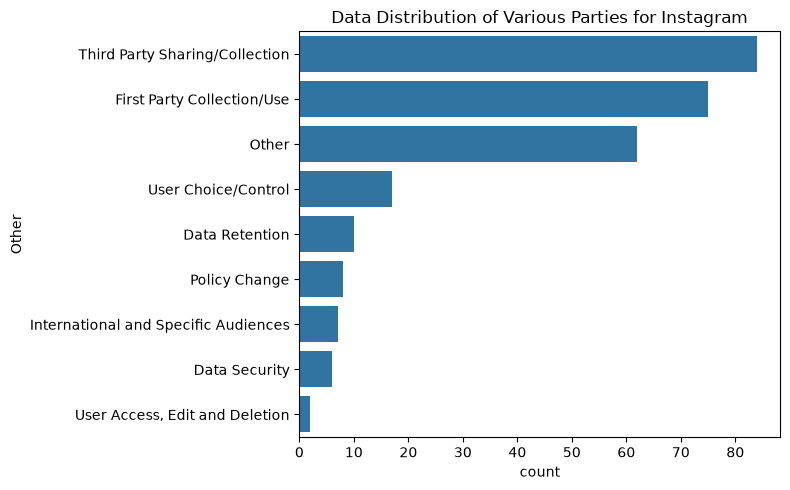

In [28]:
## visualization of the first and third party groups 
order = df_insta["Other"].value_counts().index
plt.figure(figsize=(8, 5))
sns.countplot(data=df_insta, y="Other", order=order)
plt.title("Data Distribution of Various Parties for Instagram")
plt.tight_layout()
plt.show()

Takeaway:
Peaked more interest and curiousity regarding the values of the data distribution colums
may need to label the columns more clearly in order to get a better understanding

In [19]:
## Site 2: Fox Sports

df_foxsports = pd.read_csv('/Users/paolohalog/Downloads/OPP-115/annotations/1708_foxsports.com.csv')
df_foxsports.head()

,21285,test_category_labeling_highlight_upitt,95,3842,0,Other,"{""Other Type"": {""selectedText"": ""Privacy Policy Effective Date: June 11, 2015"", ""startIndexInSegment"": 0, ""endIndexInSegment"": 44, ""value"": ""Introductory/Generic""}}",6/11/15,http://www.foxsports.com/privacy-policy
0,20573,test_category_labeling_highlight_upitt,103,3842,1,Other,"{""Other Type"": {""selectedText"": ""1. Introducti...",6/11/15,http://www.foxsports.com/privacy-policy
1,21286,test_category_labeling_highlight_upitt,95,3842,1,Other,"{""Other Type"": {""selectedText"": ""1. Introducti...",6/11/15,http://www.foxsports.com/privacy-policy
2,20574,test_category_labeling_highlight_upitt,103,3842,2,Other,"{""Other Type"": {""selectedText"": ""To see a list...",6/11/15,http://www.foxsports.com/privacy-policy
3,21287,test_category_labeling_highlight_upitt,95,3842,2,Other,"{""Other Type"": {""selectedText"": ""By providing ...",6/11/15,http://www.foxsports.com/privacy-policy
4,20575,test_category_labeling_highlight_upitt,103,3842,3,International and Specific Audiences,"{""Audience Type"": {""selectedText"": ""As set for...",6/11/15,http://www.foxsports.com/privacy-policy


In [21]:
df_foxsports.describe()
## need to grasp an undestanding of what this distrubtion is

,21285,95,3842,0
count,254.000000,254.000000,254.0,254.000000
mean,21714.125984,107.114173,3842.0,18.374016
std,883.702582,9.791440,0.0,9.964655
min,20573.000000,95.000000,3842.0,0.000000
25%,20740.250000,95.000000,3842.0,9.000000
50%,21339.000000,103.000000,3842.0,20.000000
75%,22679.750000,118.000000,3842.0,26.000000
max,22791.000000,118.000000,3842.0,38.000000


In [23]:
df_foxsports.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column                                                                                                                                                                Non-Null Count  Dtype
---  ------                                                                                                                                                                --------------  -----
 0   21285                                                                                                                                                                 254 non-null    int64
 1   test_category_labeling_highlight_upitt                                                                                                                                254 non-null    str  
 2   95                                                                                                                                

In [25]:
df_foxsports['Other'].value_counts()

Other
First Party Collection/Use              93
Third Party Sharing/Collection          68
Other                                   35
User Choice/Control                     24
Data Retention                           8
International and Specific Audiences     7
Data Security                            7
User Access, Edit and Deletion           5
Policy Change                            4
Do Not Track                             3
Name: count, dtype: int64

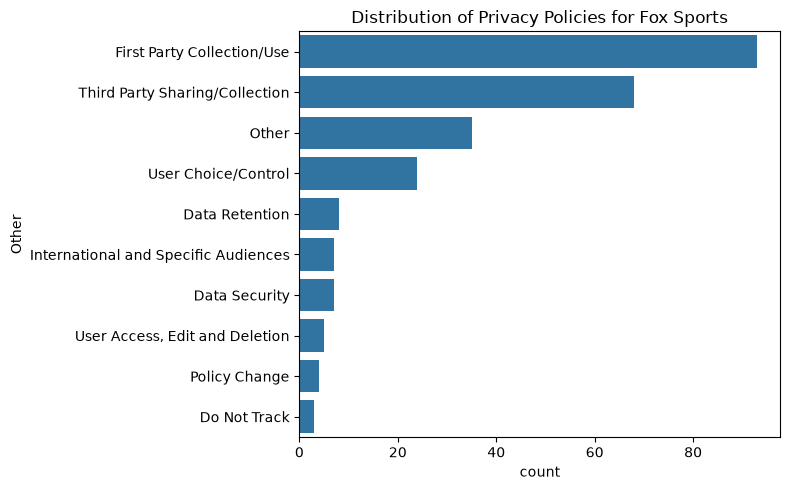

In [27]:
## visualization of the first and third party groups
order = df_foxsports["Other"].value_counts().index
plt.figure(figsize=(8, 5))
sns.countplot(data=df_foxsports, y="Other", order=order)
plt.title("Distribution of Privacy Policies for Fox Sports")
plt.tight_layout()
plt.show()

In [29]:
## Site 3: Google.com

df_google = pd.read_csv('/Users/paolohalog/Downloads/OPP-115/annotations/591_google.com.csv')
df_google.head()

,15956,test_category_labeling_highlight_fordham_bbbbb,116,3864,0,Other,"{""Other Type"": {""selectedText"": ""Welcome to the Google Privacy Policy When you use Google services, you trust us with your information. This Privacy Policy is meant to help you understand what data we collect, why we collect it, and what we do with it. This is important; we hope you will take time to read it carefully. And remember, you can find controls to manage your information and protect your privacy and security at My Account."", ""startIndexInSegment"": 0, ""endIndexInSegment"": 432, ""value"": ""Introductory/Generic""}}",6/30/15,https://www.google.com/intl/en/policies/privacy/
0,15957,test_category_labeling_highlight_fordham_bbbbb,116,3864,1,Policy Change,"{""Change Type"": {""selectedText"": ""Privacy Poli...",6/30/15,https://www.google.com/intl/en/policies/privacy/
1,15958,test_category_labeling_highlight_fordham_bbbbb,116,3864,2,Other,"{""Other Type"": {""selectedText"": ""There are man...",6/30/15,https://www.google.com/intl/en/policies/privacy/
2,15959,test_category_labeling_highlight_fordham_bbbbb,116,3864,2,First Party Collection/Use,"{""Collection Mode"": {""selectedText"": ""When you...",6/30/15,https://www.google.com/intl/en/policies/privacy/
3,15961,test_category_labeling_highlight_fordham_bbbbb,116,3864,2,First Party Collection/Use,"{""Collection Mode"": {""selectedText"": ""When you...",6/30/15,https://www.google.com/intl/en/policies/privacy/
4,15962,test_category_labeling_highlight_fordham_bbbbb,116,3864,2,First Party Collection/Use,"{""Collection Mode"": {""selectedText"": ""When you...",6/30/15,https://www.google.com/intl/en/policies/privacy/


In [32]:
df_google.shape

(291, 9)

In [33]:
df_google.info()

<class 'pandas.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 9 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                                                                                                                                       

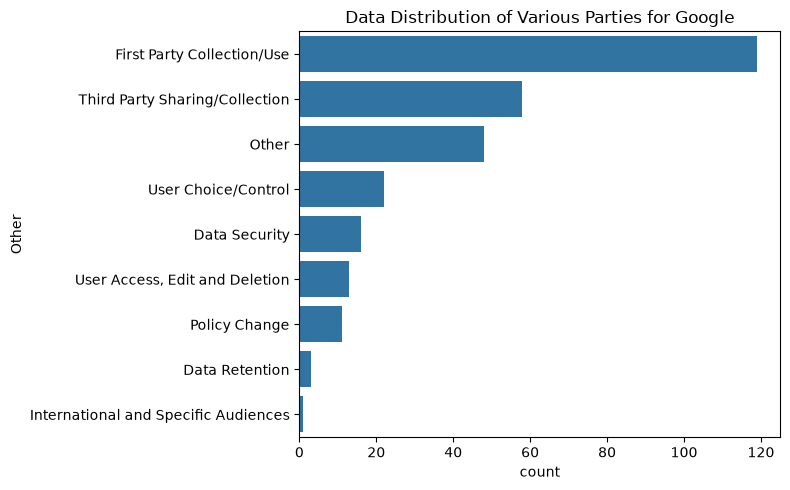

In [34]:
## attempt a visualiztion for Google

order = df_google["Other"].value_counts().index
plt.figure(figsize=(8, 5))
sns.countplot(data=df_google, y="Other", order=order)
plt.title("Data Distribution of Various Parties for Google")
plt.tight_layout()
plt.show()